In [1]:
# Pandas libaries
import pandas as pd
import numpy as np
# Split test trains
from sklearn.model_selection import train_test_split

# Preprocessing modelings
from sklearn.preprocessing import StandardScaler

# Add PCA
from sklearn.decomposition import PCA

# KNN classifer
from sklearn.neighbors import KNeighborsClassifier

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Naibe Bayes
from sklearn.naive_bayes import GaussianNB

# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("ObesityDataset_no_outlier.csv")

In [3]:
# Chia ra để có 1 df dùng để train và 1 target 
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# on hot encoding - Split train
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [4]:
classifiers = {  'KNN - mean' : KNeighborsClassifier(),
                'LogisticRegression' : LogisticRegression(),
    'Naive Bayes (NB)': GaussianNB(),
    'Random Forest Classifier': RandomForestClassifier()
 }

In [9]:
model_matrix = {}
model_performance = {}
for name, clf in classifiers.items():
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    model_performance[name] = accuracy
    model_matrix[name] = confusion_matrix(y_test, y_pred)
    print(f"PCA for model {name} report:\n")
    print(f"Accuracy: {accuracy:.3f}\n")
    print(classification_report(y_test, y_pred))

best_model_name = max(model_performance, key=model_performance.get)
best_model_accuracy = model_performance[best_model_name]

PCA for model KNN - mean report:

Accuracy: 0.726

                     precision    recall  f1-score   support

Insufficient_Weight       0.64      0.80      0.71        56
      Normal_Weight       0.55      0.68      0.61        62
     Obesity_Type_I       0.78      0.67      0.72        78
    Obesity_Type_II       0.89      0.83      0.86        58
   Obesity_Type_III       0.93      1.00      0.96        63
 Overweight_Level_I       0.69      0.55      0.61        56
Overweight_Level_II       0.60      0.52      0.56        50

           accuracy                           0.73       423
          macro avg       0.73      0.72      0.72       423
       weighted avg       0.73      0.73      0.72       423

PCA for model LogisticRegression report:

Accuracy: 0.478

                     precision    recall  f1-score   support

Insufficient_Weight       0.30      0.18      0.22        56
      Normal_Weight       0.44      0.40      0.42        62
     Obesity_Type_I       0.41  


Creating Confusion Matrix Heatmap...

Creating Confusion Matrix Heatmap...

Creating Confusion Matrix Heatmap...

Creating Confusion Matrix Heatmap...


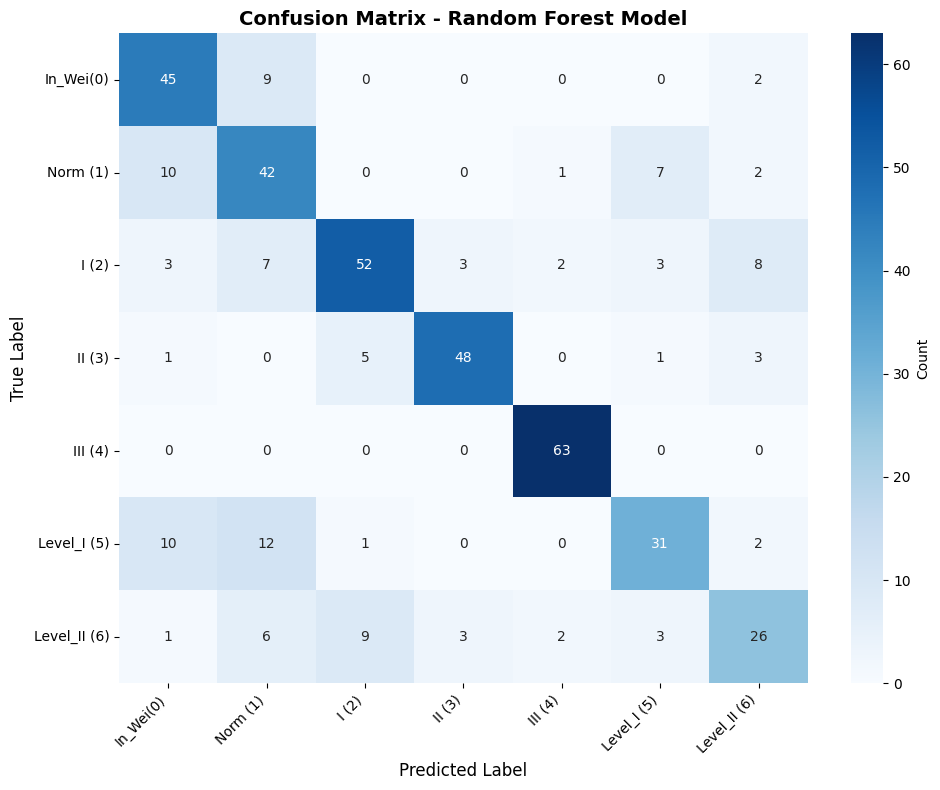

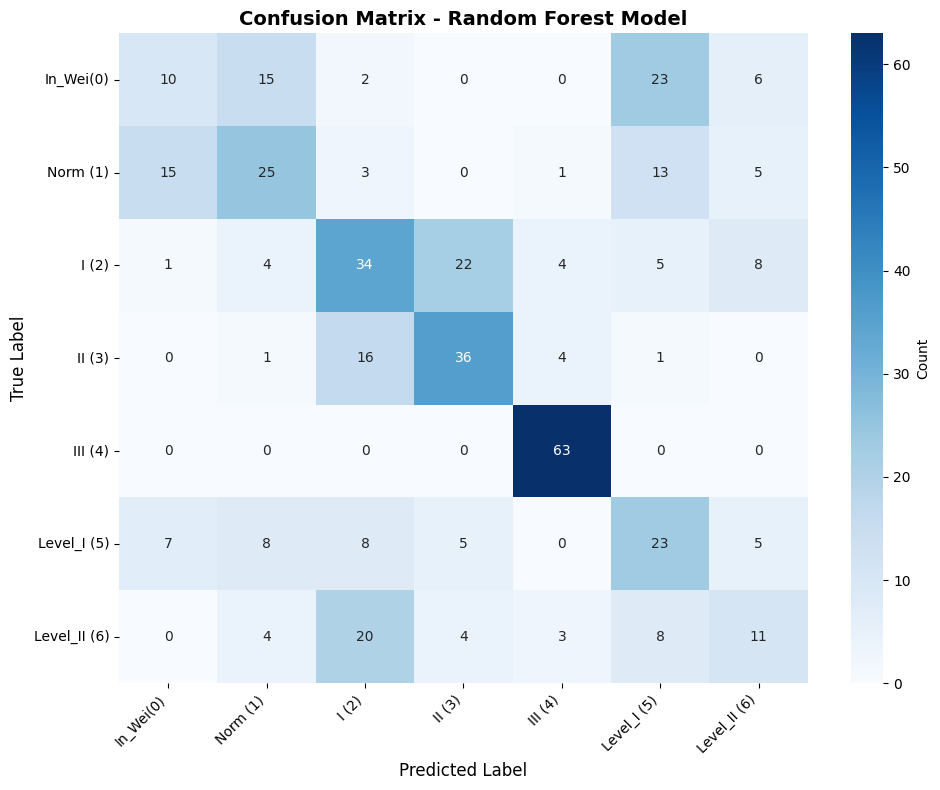

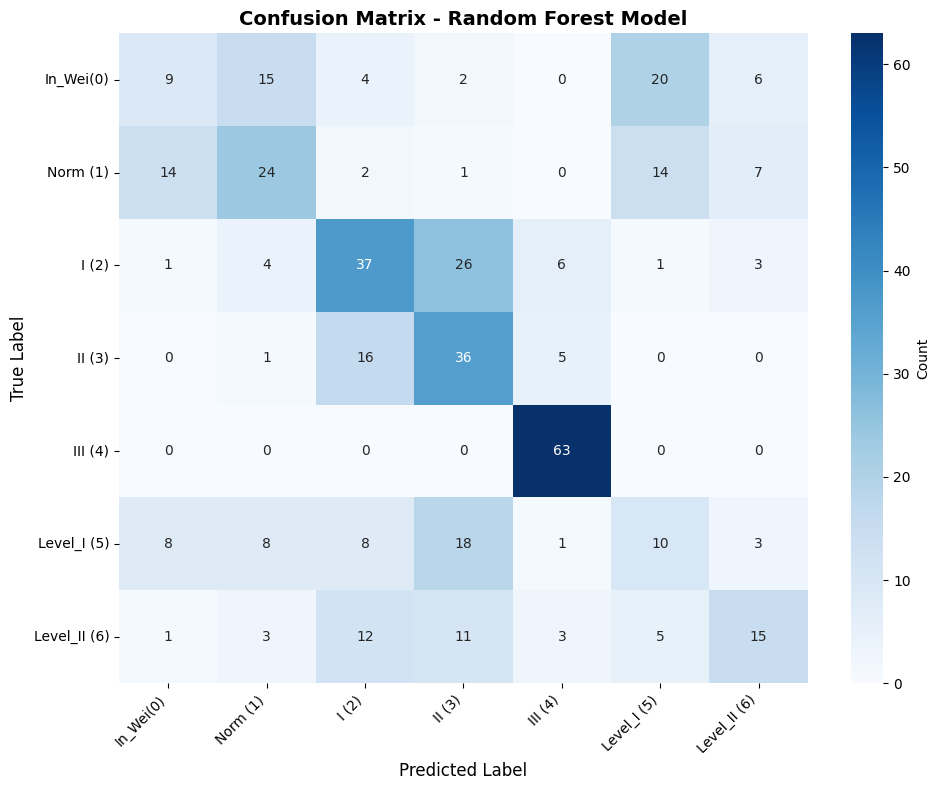

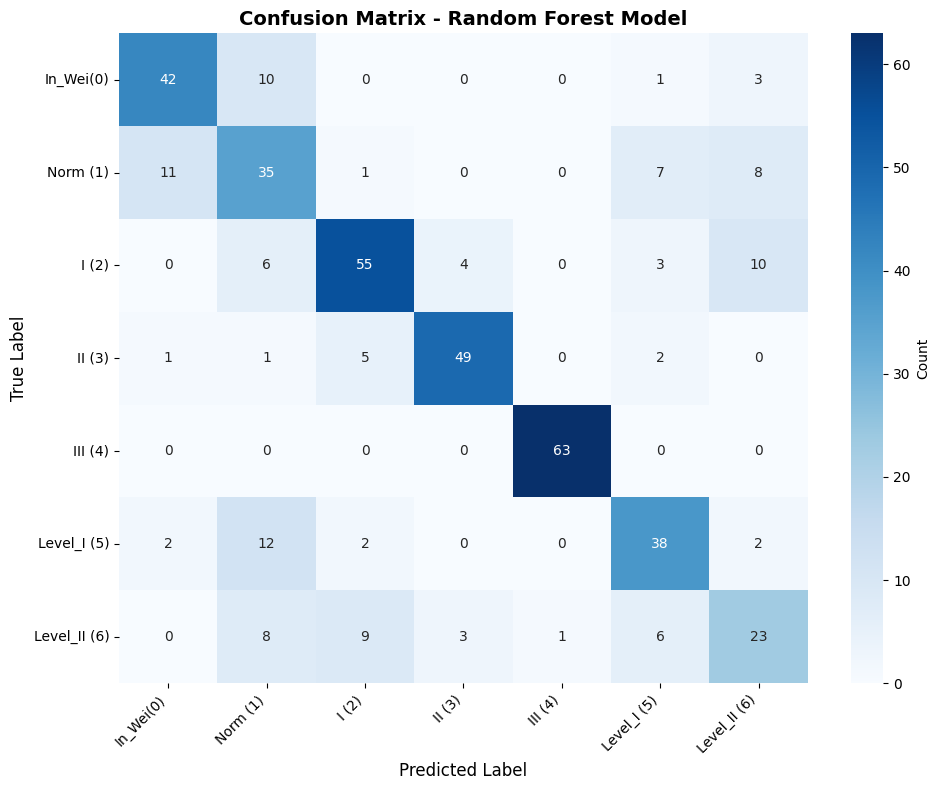

In [11]:
classes = ['In_Wei(0)', 'Norm (1)', 'I (2)', 'II (3)', 'III (4)', 'Level_I (5)', 'Level_II (6)']
for name, matrix in model_matrix.items():
    if name == best_model_name:
        best_matrix = matrix
        best_y_pred = classifiers[name].predict(X_test_pca)
    print("\nCreating Confusion Matrix Heatmap...")
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, 
                yticklabels=classes, ax=ax, cbar_kws={'label': 'Count'})
    ax.set_title('Confusion Matrix - Random Forest Model', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    name_file = "confusion_matrix" + name + ".png"
    plt.savefig("outputs" + name_file, dpi=300, bbox_inches='tight')
